In [1]:
# notebook to play around with intersection between COSMIC variants and dELS

In [1]:
# import packages
import pandas as pd
import numpy as np
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as mpl
import matplotlib
import torch
import os
import pybedtools
from collections import Counter
# tangermeme packages
from tangermeme.seqlet import recursive_seqlets
from tangermeme.plot import plot_logo
from tangermeme.annotate import annotate_seqlets
from tangermeme.io import read_meme
# set display
pd.set_option('display.max_rows', 500)
import logomaker

In [2]:
# define a function for reading in data and concatenating #
def read_in_sat_mut (path2satmut, chunksize):
    # define a list for concatenating #
    chunks2cat = []
    # iterate through chunked tsv #
    for chunk in tqdm(pd.read_csv(path2satmut, sep = '\t', chunksize=chunksize)):
        chunks2cat.append(chunk)
    # concatenate chunks #
    cat_df = pd.concat(chunks2cat)
    return cat_df

In [3]:
# open cosmic bed file and encode cCRE bed file for identifying interesting examples
# cosmic bed
cosmic_bed = pybedtools.BedTool('../processed_data/all.cosmic.v98.autosome.with.10bp.indels.bed')
# K562 cCRE
k562_cCRE = pybedtools.BedTool('../raw_data/ENCFF414OGC_ENCFF806YEZ_ENCFF849TDM_ENCFF736UDR_K562_cCRE.bed')
# HepG2 cCRE
hepg2_cCRE = pybedtools.BedTool('../raw_data/ENCFF546MZK_ENCFF732PJK_ENCFF795ONN_ENCFF357NFO_HepG2_cCRE.bed')
# SKNSH cCRE
sknsh_cCRE = pybedtools.BedTool('../raw_data/ENCFF280RMA_ENCFF651WOM_ENCFF262UEH_ENCFF850MLW_SKNSH_cCRE.bed')
# ENCODE cell agnostic cCRE
all_dELS = pybedtools.BedTool.from_dataframe(pybedtools.BedTool('../processed_data/GRCh38-dELS-only.bed').to_dataframe().filter(['chrom', 'start', 'end', 'score']))

In [4]:
# define a function for filtering for only dELS from the cell type BED files
def encode_dels_only (cell_bed):
    # convert from bedtool to dataframe
    bed_df = cell_bed.to_dataframe()
    # filter for only dELS
    dELS_df = bed_df[bed_df['blockCount'] == 'dELS'].filter(['chrom', 'start', 'end', 'name'])
    dELS_bed = pybedtools.BedTool.from_dataframe(dELS_df)
    return dELS_bed

In [5]:
# filter full ENCODE cCRE BEDs for only dELS
# k562
k562_dELS = encode_dels_only(k562_cCRE)
# hepg2
hepg2_dELS = encode_dels_only(hepg2_cCRE)
# sknsh
sknsh_dELS = encode_dels_only(sknsh_cCRE)

In [6]:
# intersect cosmic beds with the different cCREs
# k562
cosmic_k562_dELS = cosmic_bed.intersect(k562_dELS, wa=True, wb=True).to_dataframe(names=['chrom', 'start', 'end', 'cosmic_id', 'enh_chrom', 'enh_start', 'enh_end', 'enh_id'])
# hepg2
cosmic_hepg2_dELS = cosmic_bed.intersect(hepg2_dELS, wa=True, wb=True).to_dataframe(names=['chrom', 'start', 'end', 'cosmic_id', 'enh_chrom', 'enh_start', 'enh_end', 'enh_id'])
# sknsh
cosmic_sknsh_dELS = cosmic_bed.intersect(sknsh_dELS, wa=True, wb=True).to_dataframe(names=['chrom', 'start', 'end', 'cosmic_id', 'enh_chrom', 'enh_start', 'enh_end', 'enh_id'])
# agnostic cCRE
cosmic_agnostic_dELS = cosmic_bed.intersect(all_dELS, wa=True, wb=True).to_dataframe(names=['chrom', 'start', 'end', 'cosmic_id', 'enh_chrom', 'enh_start', 'enh_end', 'enh_id'])

In [7]:
# open cosmic predictions that have been annotated with recurrence, etc.
cosmic_preds = pd.read_csv('../../../cosmic/processed_data/all.cosmic.v98.autosome.with.10bp.indels.annotated.017.011226.tsv', sep = '\t')
# make a dictionary of recurrence at the cosmic variant id
cosmic_recurrence_dict = dict(zip(cosmic_preds['id'], cosmic_preds['recurrence']))
# make a dictionary of cosmic id and whether the variant is an emVar
# any cell type
cosmic_emvar_dict = dict(zip(cosmic_preds['id'], cosmic_preds['emvar_any'])) # use this one for agnostic
# k562
cosmic_k_emvar_dict = dict(zip(cosmic_preds['id'], cosmic_preds['k562_emvar']))
# hepg2
cosmic_h_emvar_dict = dict(zip(cosmic_preds['id'], cosmic_preds['hepg2_emvar']))
# sknsh
cosmic_s_emvar_dict = dict(zip(cosmic_preds['id'], cosmic_preds['sknsh_emvar']))

In [8]:
# annotate each intersection with recurrence and emVar status
# k562
cosmic_k562_dELS.loc[:, 'recurrence'] = [cosmic_recurrence_dict.get(i) for i in cosmic_k562_dELS['cosmic_id']]
cosmic_k562_dELS.loc[:, 'k562_emVar'] = [cosmic_k_emvar_dict.get(i) for i in cosmic_k562_dELS['cosmic_id']]
# hepg2
cosmic_hepg2_dELS.loc[:, 'recurrence'] = [cosmic_recurrence_dict.get(i) for i in cosmic_hepg2_dELS['cosmic_id']]
cosmic_hepg2_dELS.loc[:, 'hepg2_emVar'] = [cosmic_h_emvar_dict.get(i) for i in cosmic_hepg2_dELS['cosmic_id']]
# sknsh
cosmic_sknsh_dELS.loc[:, 'recurrence'] = [cosmic_recurrence_dict.get(i) for i in cosmic_sknsh_dELS['cosmic_id']]
cosmic_sknsh_dELS.loc[:, 'sknsh_emVar'] = [cosmic_s_emvar_dict.get(i) for i in cosmic_sknsh_dELS['cosmic_id']]
# agnostic
cosmic_agnostic_dELS.loc[:, 'recurrence'] = [cosmic_recurrence_dict.get(i) for i in cosmic_agnostic_dELS['cosmic_id']]
cosmic_agnostic_dELS.loc[:, 'emVar_any'] = [cosmic_emvar_dict.get(i) for i in cosmic_agnostic_dELS['cosmic_id']]

In [9]:
cosmic_k562_dELS[(cosmic_k562_dELS['recurrence'] > 1) & (cosmic_k562_dELS['k562_emVar'] == 1)].sort_values(by='recurrence', ascending=False)

,chrom,start,end,cosmic_id,enh_chrom,enh_start,enh_end,enh_id,recurrence,k562_emVar
4705,chr2,43426739,43426740,COSV105215687,chr2,43426454,43426803,EH38E1992686,4,1
8017,chr8,76855595,76855596,COSV51438481,chr8,76855428,76855752,EH38E3841040,3,1
145,chr1,16146497,16146498,COSV64452057,chr1,16146312,16146660,EH38E2789293,2,1
696,chr1,155085252,155085253,COSV63625494,chr1,155085057,155085331,EH38E2839723,2,1
2893,chr16,27198936,27198937,COSV53730765,chr16,27198830,27199168,EH38E3174567,2,1
4476,chr19,49210316,49210317,COSV53262846,chr19,49210113,49210458,EH38E1960684,2,1
2214,chr12,122023950,122023951,COSV104379342,chr12,122023774,122024114,EH38E4078619,2,1
2733,chr15,90221463,90221464,COSV60172886,chr15,90221271,90221598,EH38E3154295,2,1
4595,chr19,55174270,55174270,COSV62831248,chr19,55173943,55174287,EH38E3317228,2,1
4555,chr19,50870485,50870486,COSV57569136,chr19,50870451,50870801,EH38E3314691,2,1


In [10]:
cosmic_hepg2_dELS[(cosmic_hepg2_dELS['recurrence'] > 1) & (cosmic_hepg2_dELS['hepg2_emVar'] == 1)].sort_values(by='recurrence', ascending=False)

,chrom,start,end,cosmic_id,enh_chrom,enh_start,enh_end,enh_id,recurrence,hepg2_emVar
3227,chr2,43426739,43426740,COSV105215687,chr2,43426454,43426803,EH38E1992686,4,1
84,chr1,16146497,16146498,COSV64452057,chr1,16146312,16146660,EH38E2789293,2,1
496,chr1,207337390,207337391,COSV58577793,chr1,207337123,207337473,EH38E2862336,2,1
1091,chr11,85919567,85919568,COSV104600011,chr11,85919542,85919861,EH38E2976910,2,1
1669,chr14,73478884,73478885,COSV58576208,chr14,73478633,73478916,EH38E3104140,2,1
5689,chr8,47525127,47525128,COSV52373280,chr8,47525002,47525352,EH38E2628885,2,1


In [11]:
cosmic_sknsh_dELS[(cosmic_sknsh_dELS['recurrence'] > 1) & (cosmic_sknsh_dELS['sknsh_emVar'] == 1)].sort_values(by='recurrence', ascending=False)

,chrom,start,end,cosmic_id,enh_chrom,enh_start,enh_end,enh_id,recurrence,sknsh_emVar
1478,chr2,43426739,43426740,COSV105215687,chr2,43426454,43426803,EH38E1992686,4,1
126,chr1,155085252,155085253,COSV63625494,chr1,155085057,155085331,EH38E2839723,2,1
577,chr12,113299855,113299856,COSV52526250,chr12,113299542,113299891,EH38E3042407,2,1


In [12]:
cosmic_agnostic_dELS[(cosmic_agnostic_dELS['recurrence'] > 1) & (cosmic_agnostic_dELS['emVar_any'] == 1)].sort_values(by='recurrence', ascending=False)

,chrom,start,end,cosmic_id,enh_chrom,enh_start,enh_end,enh_id,recurrence,emVar_any
312752,chr7,55191821,55191822,COSV51765161,chr7,55191712,55191899,EH38E3775532,22,1
70575,chr12,8943799,8943800,COSV50002506,chr12,8943647,8943941,EH38E3002398,7,1
269641,chr5,68295417,68295418,COSV57125460,chr5,68295324,68295664,EH38E3641404,6,1
158069,chr19,1612366,1612367,COSV53653690,chr19,1612142,1612486,EH38E3281186,6,1
86733,chr12,132717312,132717313,COSV58201962,chr12,132717154,132717393,EH38E3053454,5,1
121832,chr16,23494366,23494367,COSV59167693,chr16,23494258,23494595,EH38E3173360,4,1
246135,chr3,197476657,197476658,COSV104948820,chr3,197476425,197476721,EH38E4323710,4,1
114106,chr15,78102935,78102936,COSV105002781,chr15,78102772,78103095,EH38E3148472,4,1
112249,chr15,67878959,67878960,COSV104934068,chr15,67878792,67879092,EH38E3141997,4,1
109596,chr15,42010139,42010140,COSV68150469,chr15,42010009,42010289,EH38E3130517,4,1


In [34]:
def plot_specific_logos (annotated_seqlets,
                         cell,
                         enhancerID,
                         plotLogo_tensors,
                         varPos,
                         outpath):
    # define colors for each cell type for highlighting logos
    if cell == 'K562':
        highlight = '#00A79D'
    elif cell == 'HepG2':
        highlight = '#FBB040'
    elif cell == 'SKNSH':
        highlight = '#ED1C24'
    print(cell)
    # return index of chosen enhancer
    enh_idx = list(plotLogo_tensors[cell].keys()).index(enhancerID)
    cell_seqlets = annotated_seqlets[cell][0]
    annotation_seqlets = annotated_seqlets[cell][-1]
    # filter for the random enhancer by enhancer index
    enh_seqlets = cell_seqlets[cell_seqlets['example_idx'] == enh_idx]
    enh_ann = annotation_seqlets.iloc[enh_seqlets.index]
    if len(enh_seqlets) > 0:
        matplotlib.rcParams['pdf.fonttype'] = 42
        matplotlib.rcParams['ps.fonttype'] = 42
        tensors2plot = plotLogo_tensors[cell][enhancerID]
        # get the minimum and maximum attributions for plotting
        minAttrib = tensors2plot.min().min() * 1.05
        maxAttrib = tensors2plot.max().max() * 1.05
        dfFromTensor = pd.DataFrame(tensors2plot.numpy()).T.copy() # convert tensor to DF for plotting with logoMaker
        renamedDF = dfFromTensor.rename(columns={0 : 'A', 1 : 'C', 2 : 'G', 3 : 'T'})
        logoCheck = logomaker.Logo(renamedDF, figsize=[12,2])
        logoCheck.style_spines(visible=False)
        for idx, row in enh_ann.iterrows():
            start, stop, tf = row[['start', 'end', 'example_idx']].tolist() # add attribution score to plot for annotating TFs
            logoCheck.highlight_position_range(pmin=start, pmax=stop, alpha=0.5, color='blanchedalmond')
            logoCheck.ax.plot([start, stop],
            [maxAttrib*1.05, maxAttrib*1.05], color='k', linewidth=1, solid_capstyle='butt')
            logoCheck.ax.text((stop+start) / 2,maxAttrib*1.15,f'${tf.split('_')[0]}$',fontsize=8,verticalalignment='top', horizontalalignment='center')
            logoCheck.highlight_position(p=varPos, color='red',alpha=0.1)
        #mpl.ylim(-.5, .5)
        mpl.title(f'{enhancerID}| {cell}', loc='left')
        mpl.tight_layout()
        mpl.savefig(outpath, dpi=300)
    # else:
    #     print('no seqlets for this enhancer at this threshold')
    #     mpl.figure(figsize=(20,1), dpi=300)
    #     plot_logo(plotLogo_tensors[cell][enhancerID])
    #     mpl.title(f'tangermeme seqlets for {enhancerID}, threshold: 0.01 | {cell}')
    #     mpl.show()

In [35]:
# define function for plotting logos including opening preds, etc.
def plot_logos_v2 (chrom,
                   cell,
                   enhancer_id,
                   varPos,
                   outPath):
    # load plotLogo_tensors
    plotLogos = torch.load(f'/projects/tewhey-lab/buttsj/Variant_Effects/revision_experiments/distal_cre_sat_mut/encode_cCRE_all/processed_data/seqlets_calling/seqlets_by_chrom/chr{chrom}_plotLogo_tensors.pt')
    # load annotated seqlets
    ann_seqlets = torch.load(f'/projects/tewhey-lab/buttsj/Variant_Effects/revision_experiments/distal_cre_sat_mut/encode_cCRE_all/processed_data/seqlets_calling/seqlets_by_chrom/annotated_seqlets/chr{chrom}_annotated_seqlets_0.01.pt',
                             weights_only=False)
    # plot the logo
    plot_specific_logos(
        ann_seqlets,
        cell,
        enhancer_id,
        plotLogos,
        varPos,
        outPath
    )

SKNSH


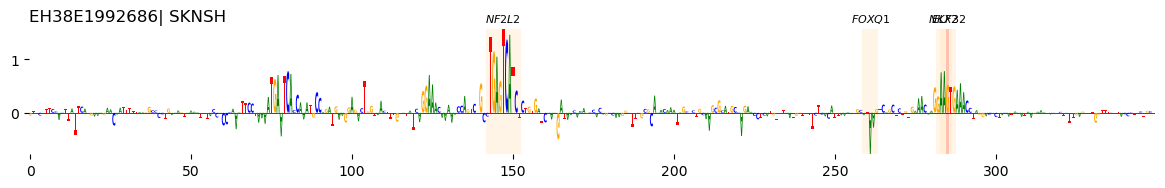

In [36]:
# chr2 43426739 43426740 COSV105215687 - emVar in all three cell types ***** chr2:43,426,454-43,426,803
# k562
# plot_logos_v2(
#     2,
#     'K562',
#     'EH38E1992686'
# )
# # hepg2
# plot_logos_v2(
#     2,
#     'HepG2',
#     'EH38E1992686'
# )
# sknsh
plot_logos_v2(
    2,
    'SKNSH',
    'EH38E1992686',
    43426740 - 43426454 - 1, # variant position minus start of enhancer
    '../analyses/figures/EH38E1992686_COSV105215687_Contribution.pdf'
)

K562
HepG2
SKNSH


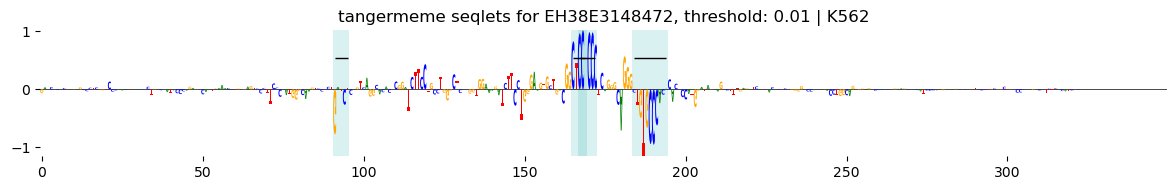

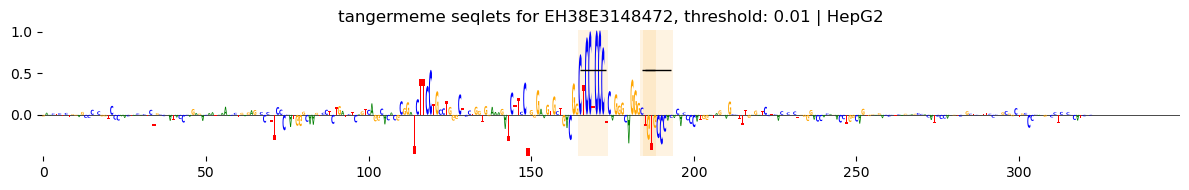

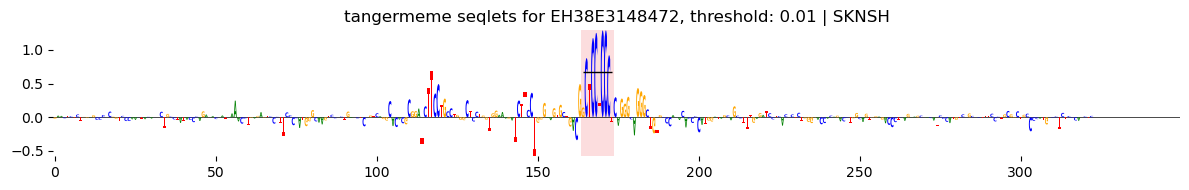

In [35]:
# chr15 	78102935 	78102936 	COSV105002781 	chr15 	78102772 	78103095 	EH38E3148472 	4
# k562
plot_logos_v2(
    15,
    'K562',
    'EH38E3148472'
)
# hepg2
plot_logos_v2(
    15,
    'HepG2',
    'EH38E3148472'
)
# sknsh
plot_logos_v2(
    15,
    'SKNSH',
    'EH38E3148472'
)

In [16]:
cosmic_preds[cosmic_preds['id'] == 'COSV105002781'].filter(['id', 'var_id', 'k562_skew_pred', 'hepg2_skew_pred', 'sknsh_skew_pred', 'recurrence'])

,id,var_id,k562_skew_pred,hepg2_skew_pred,sknsh_skew_pred,recurrence
1319948,COSV105002781,chr15:78102936:G:A,-0.282059,-0.370626,-0.519323,4


K562
HepG2
SKNSH


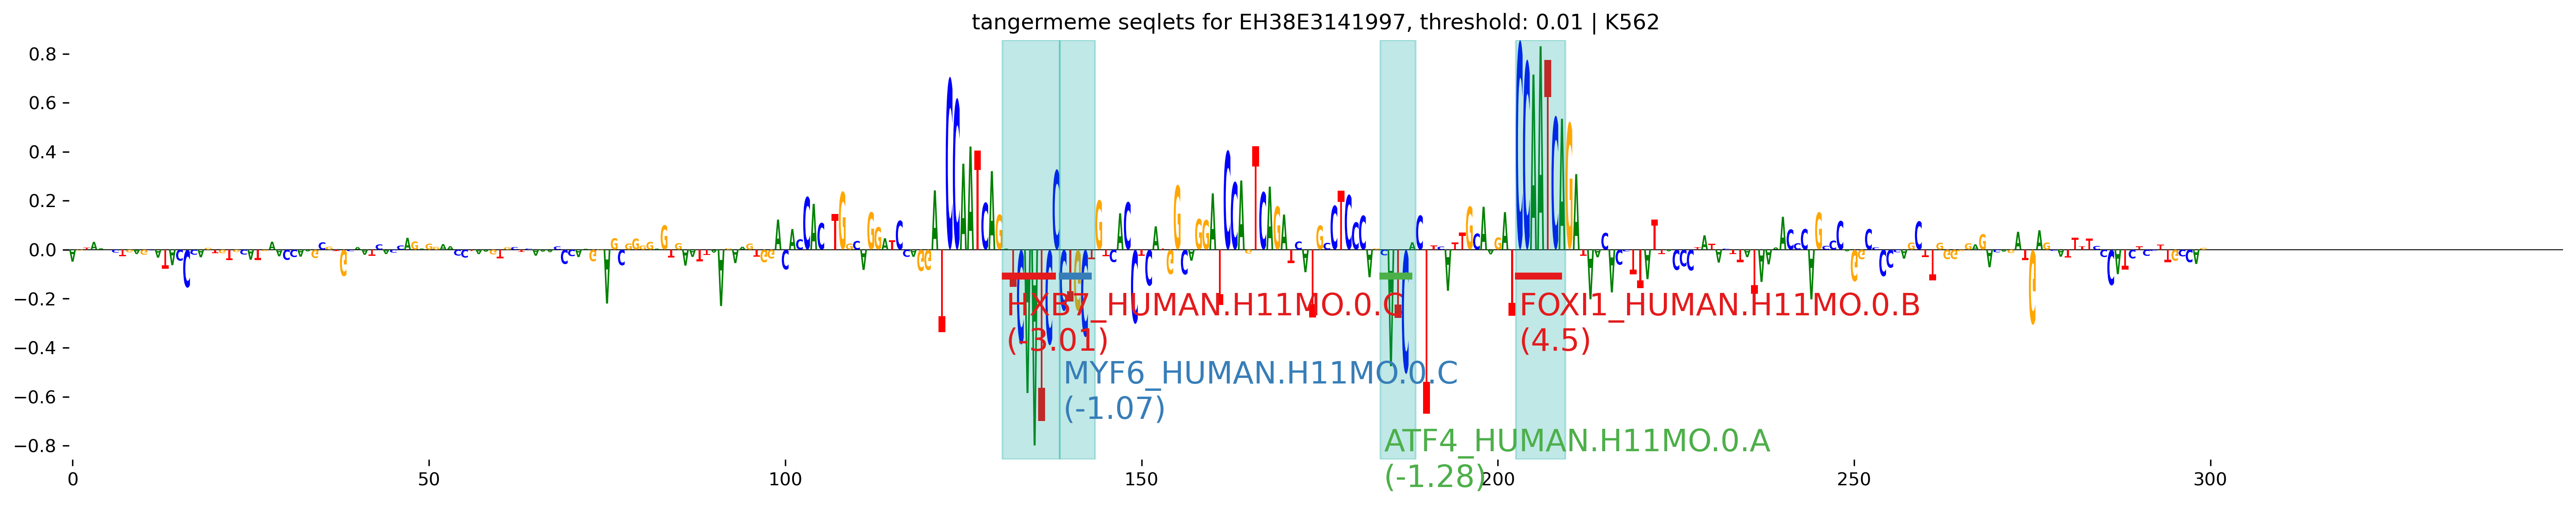

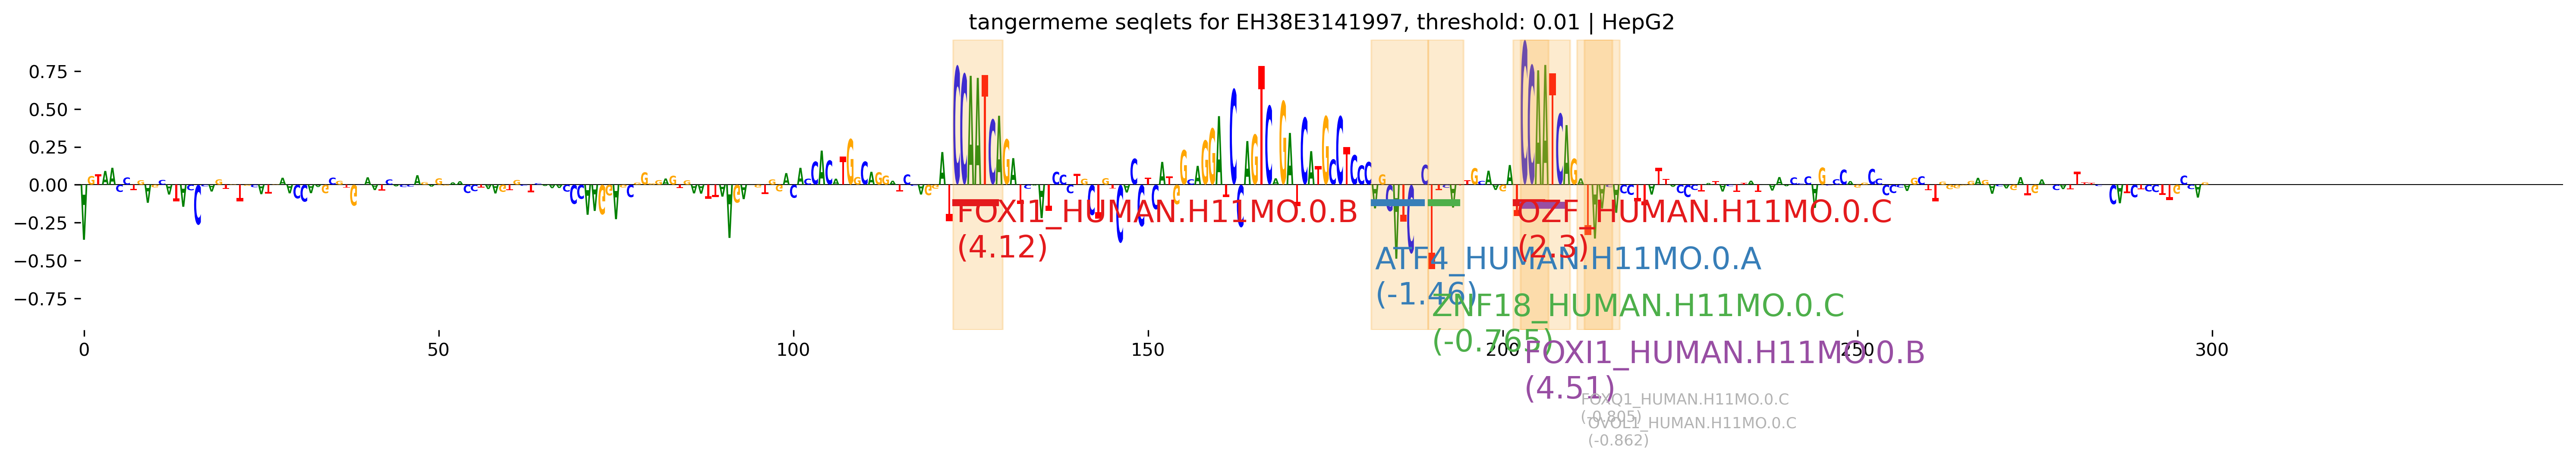

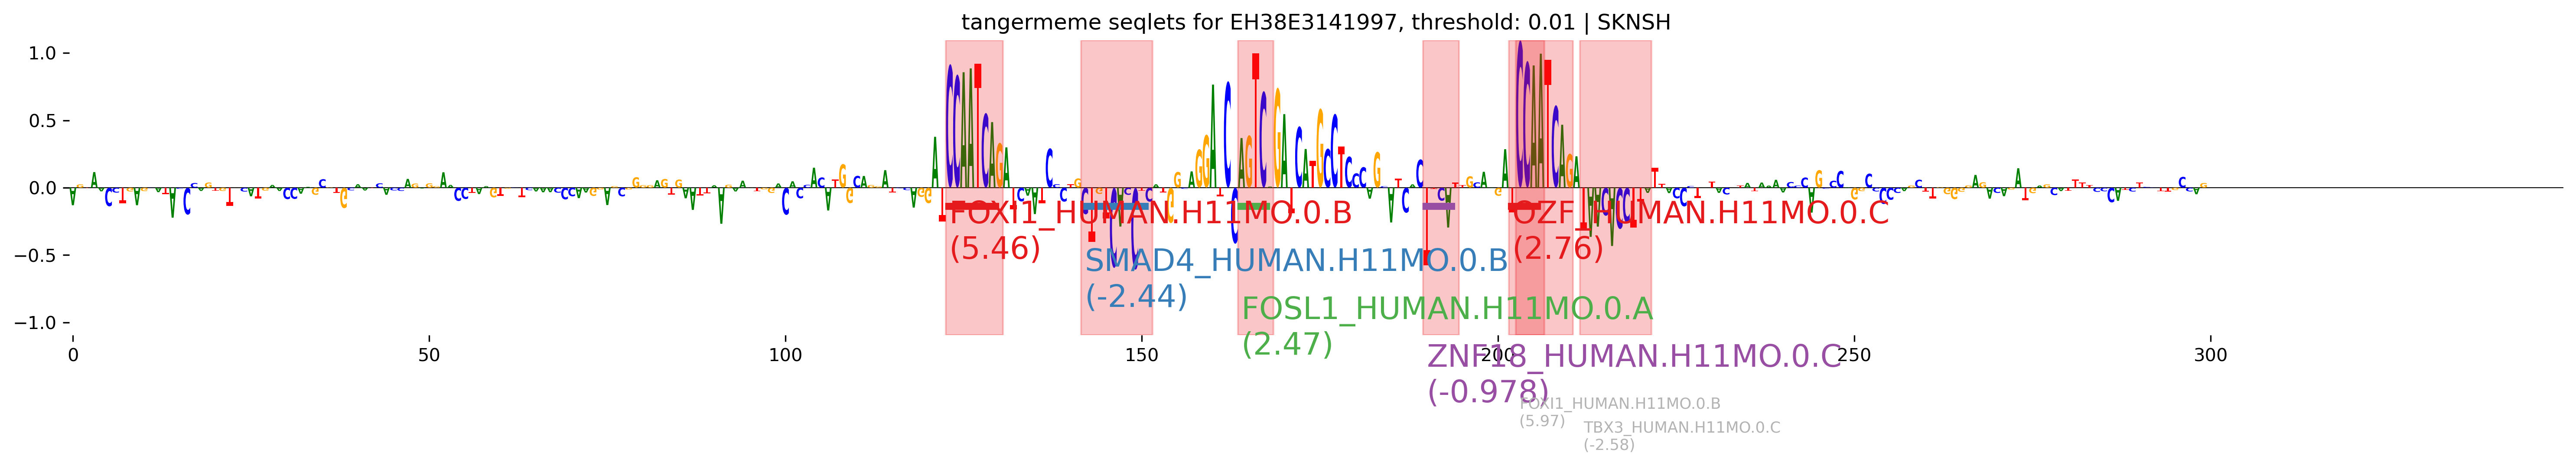

In [42]:
# chr15 	67878959 	67878960 	COSV104934068 	chr15 	67878792 	67879092 	EH38E3141997 	4
# k562
plot_logos_v2(
    15,
    'K562',
    'EH38E3141997'
)
# hepg2
plot_logos_v2(
    15,
    'HepG2',
    'EH38E3141997'
)
# sknsh
plot_logos_v2(
    15,
    'SKNSH',
    'EH38E3141997'
)

In [43]:
cosmic_preds[cosmic_preds['id'] == 'COSV104934068'].filter(['id', 'var_id', 'k562_skew_pred', 'hepg2_skew_pred', 'sknsh_skew_pred', 'recurrence'])

,id,var_id,k562_skew_pred,hepg2_skew_pred,sknsh_skew_pred,recurrence
1312516,COSV104934068,chr15:67878960:C:T,-0.274613,-0.429048,-0.581074,4


K562
HepG2
SKNSH


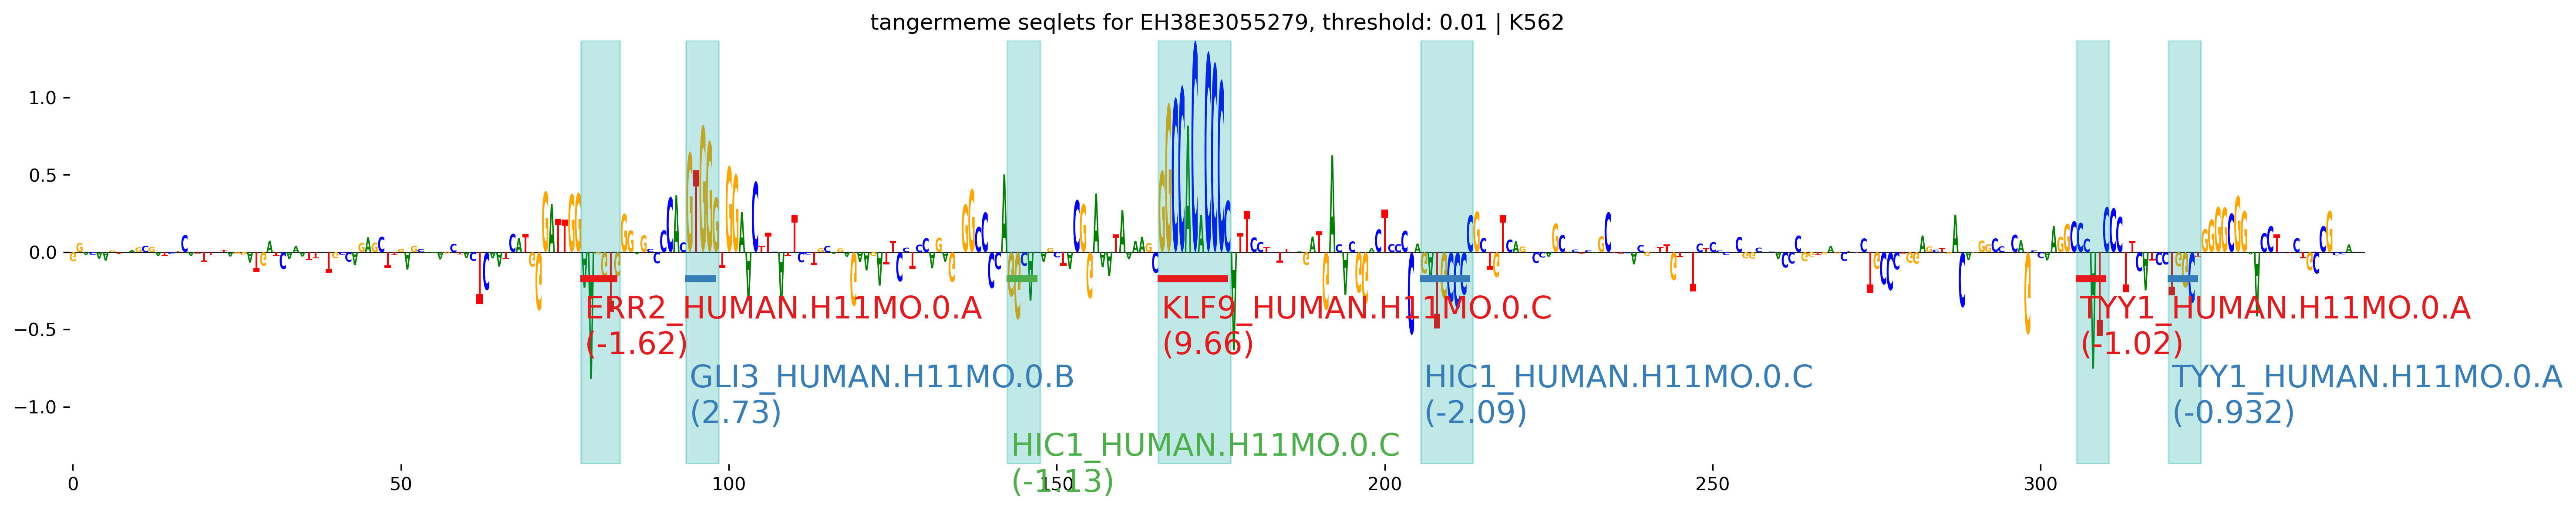

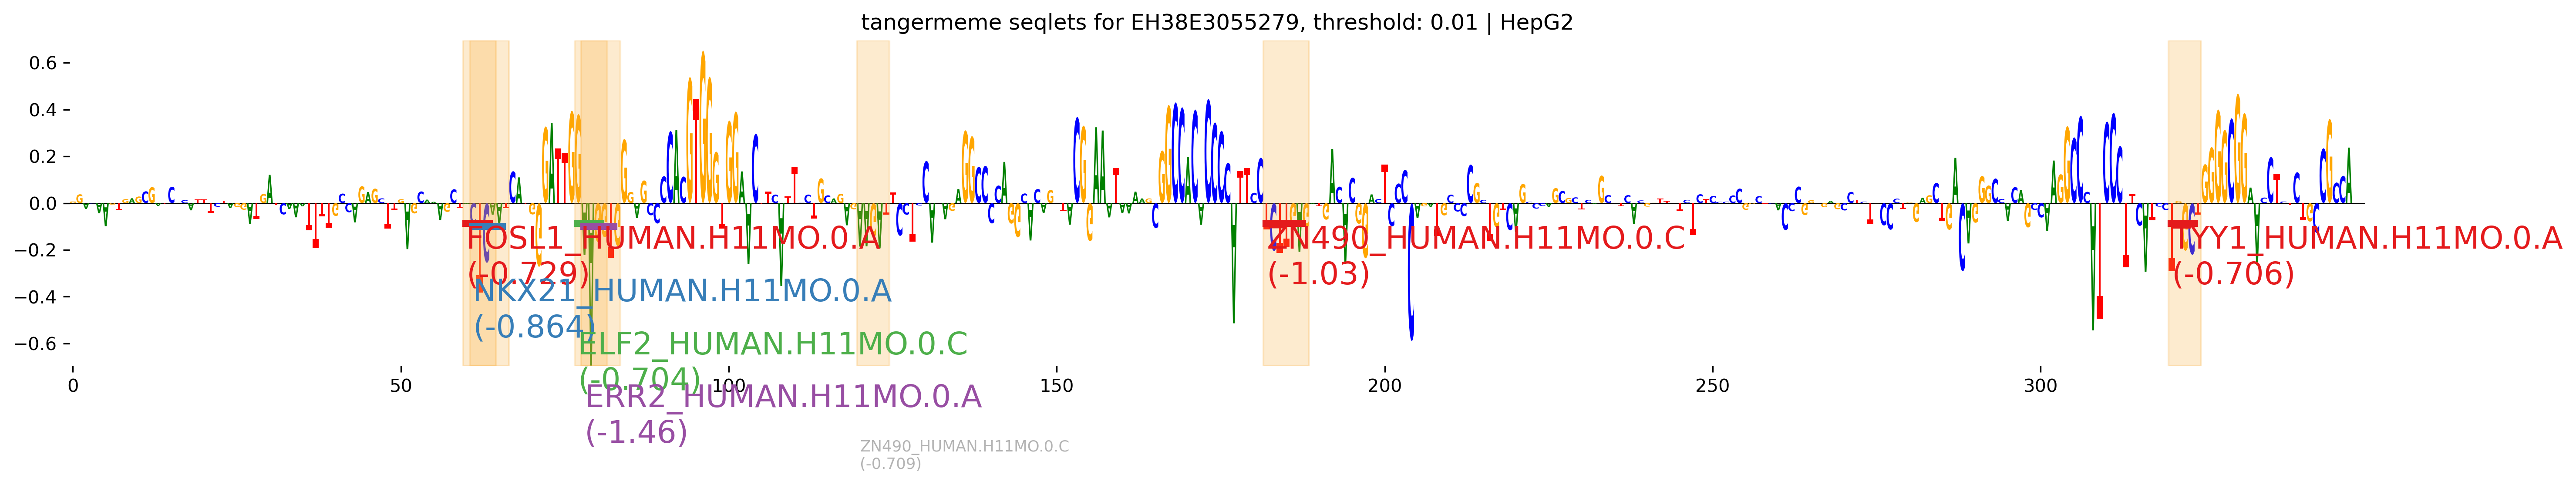

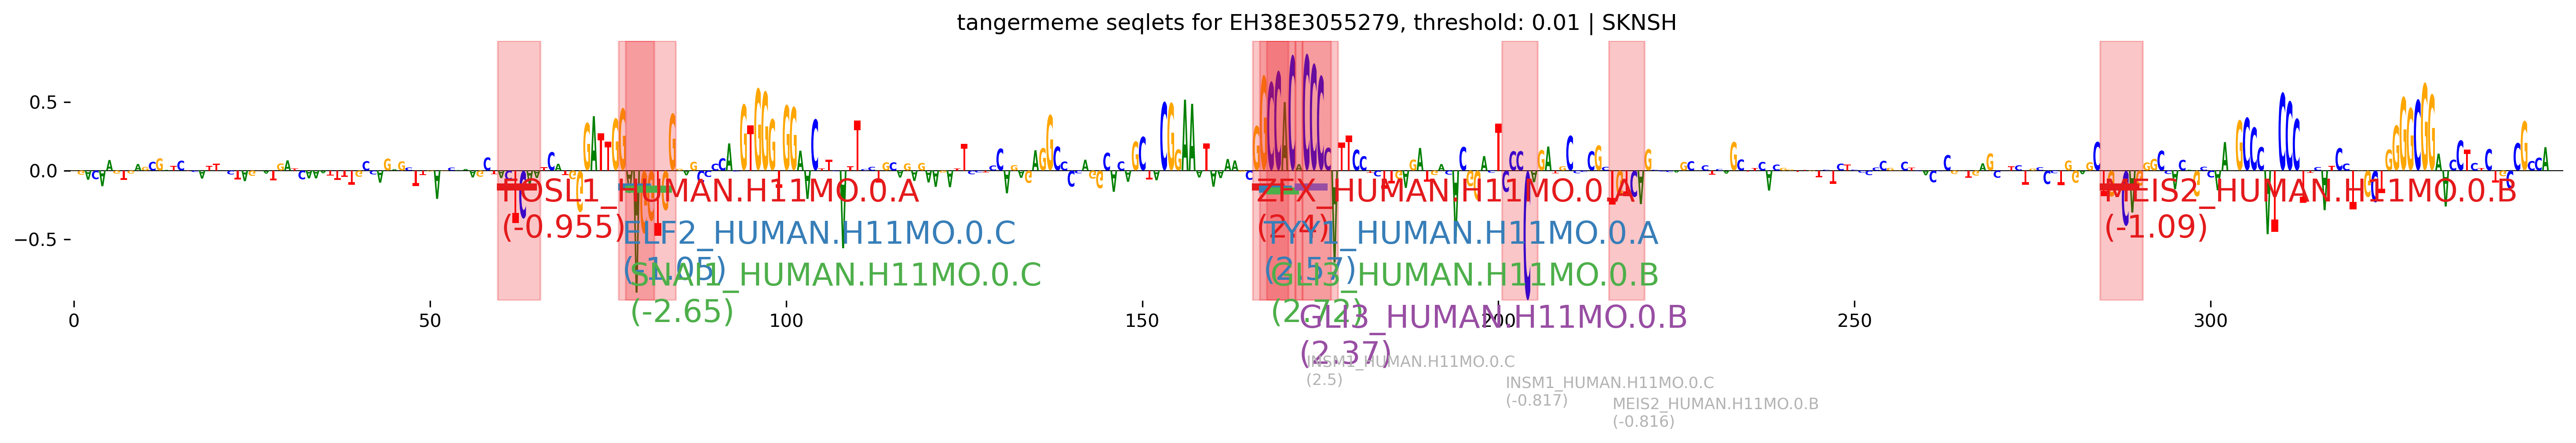

In [30]:
# chr13 	22965371 	22965372 	COSV53295144
# chr13 	22965364 	22965365 	COSV53295129 - two recurrent variants in a single enhancer
# k562
plot_logos_v2(
    13,
    'K562',
    'EH38E3055279'
)
# hepg2
plot_logos_v2(
    13,
    'HepG2',
    'EH38E3055279'
)
# sknsh
plot_logos_v2(
    13,
    'SKNSH',
    'EH38E3055279'
)

In [32]:
cosmic_preds[cosmic_preds['id'].isin(['COSV53295144', 'COSV53295129'])].filter(['id','var_id','k562_skew_pred', 'hepg2_skew_pred', 'sknsh_skew_pred', 'recurrence'])

,id,var_id,k562_skew_pred,hepg2_skew_pred,sknsh_skew_pred,recurrence
1847966,COSV53295129,chr13:22965365:T:C,-0.639091,-0.527291,-0.465353,2
1847968,COSV53295144,chr13:22965372:A:C,-0.669104,-0.411358,-0.455804,2


K562
HepG2
SKNSH


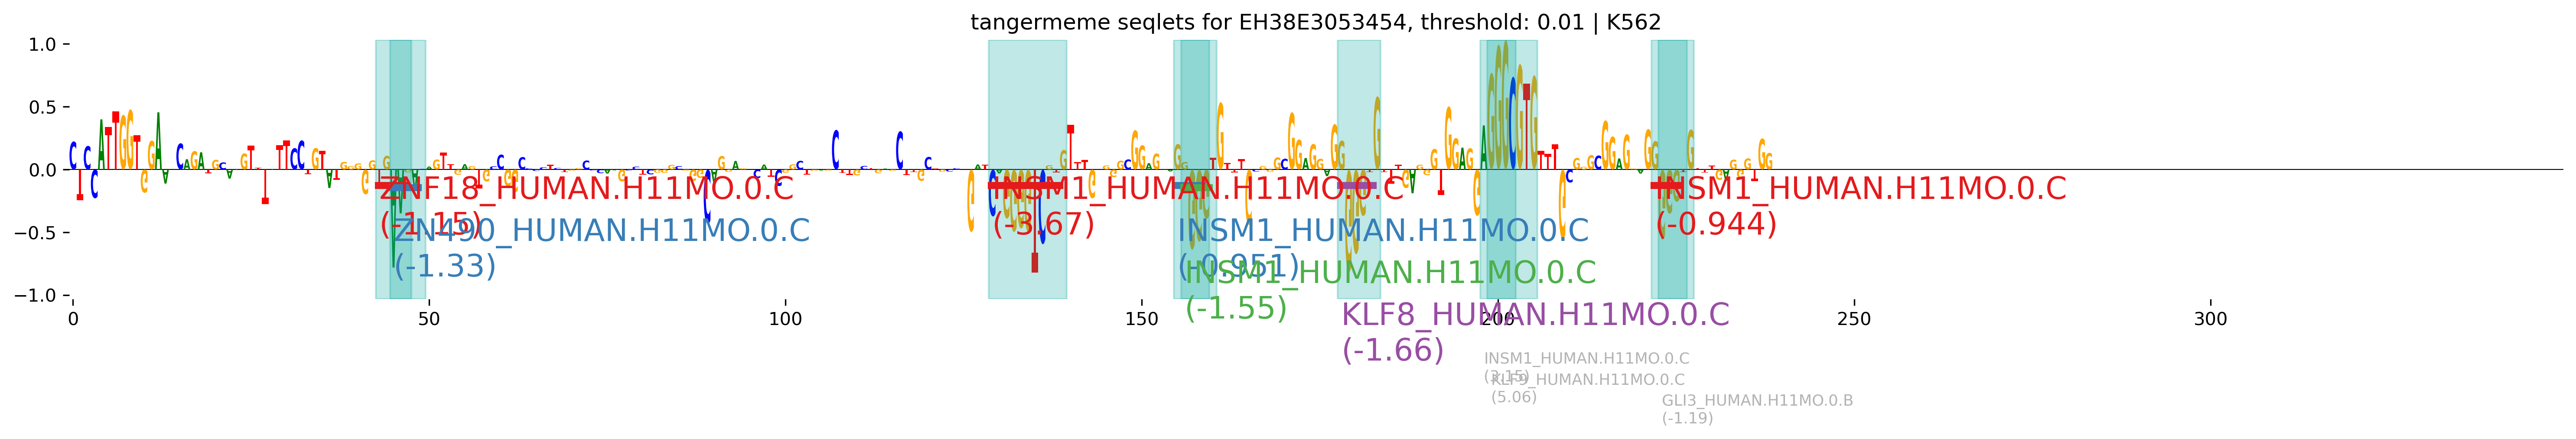

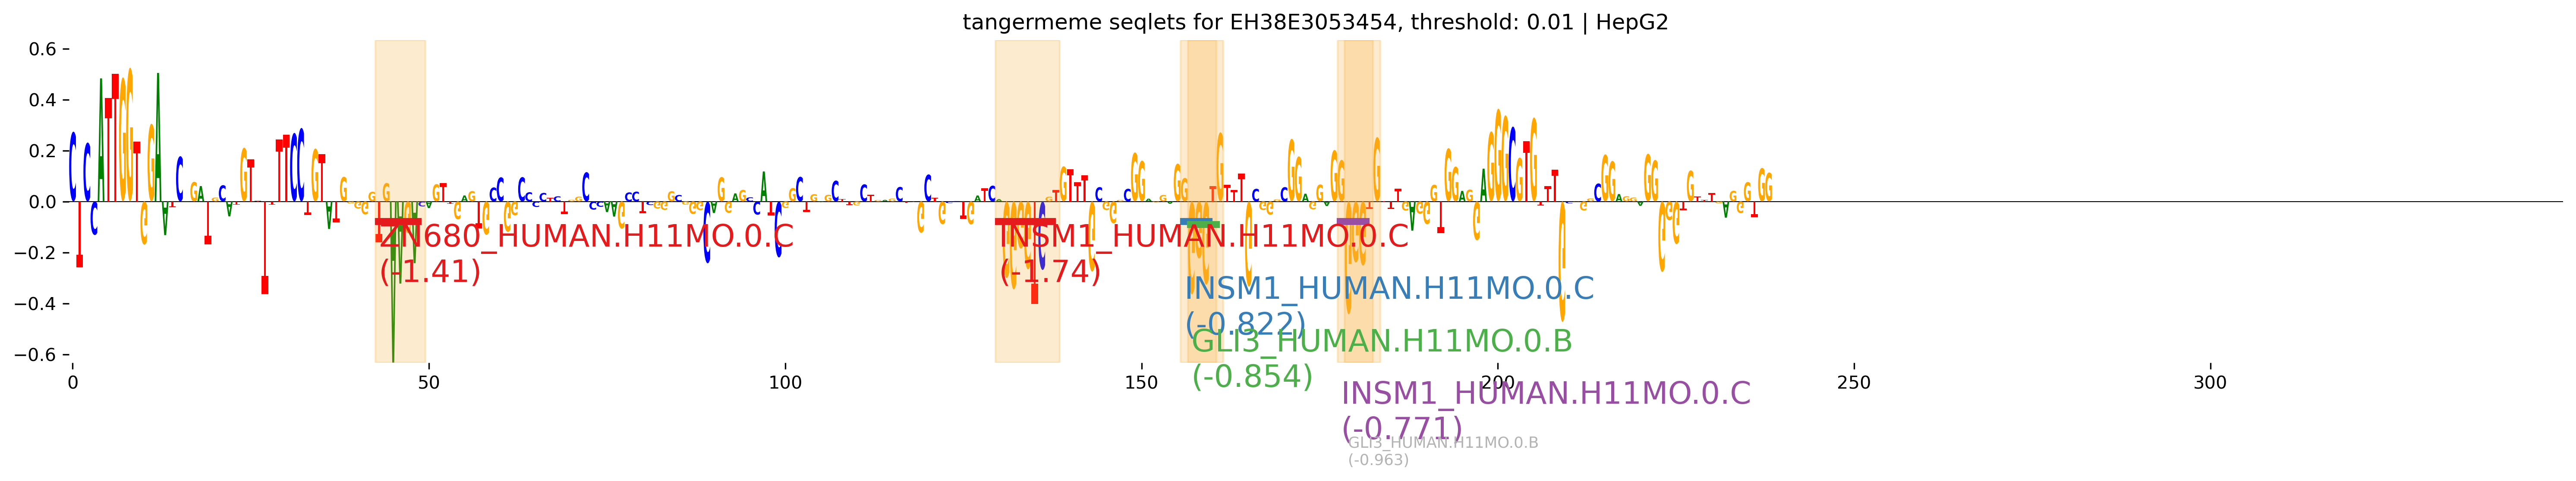

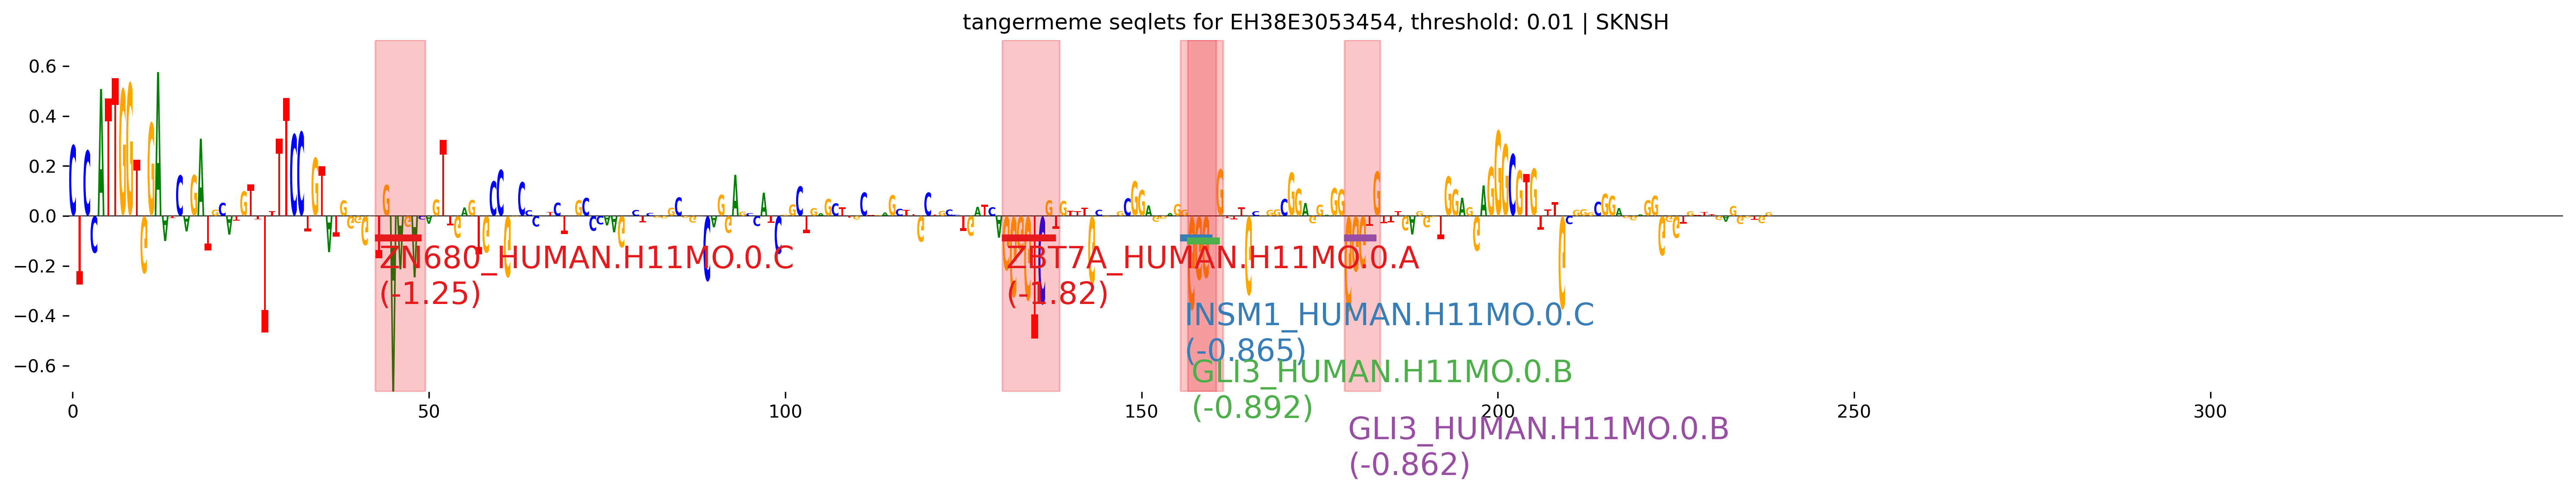

In [34]:
# chr12 	132717312 	132717313 	COSV58201962 	chr12 	132717154 	132717393 	EH38E3053454 	5 	1
# k562
plot_logos_v2(
    12,
    'K562',
    'EH38E3053454'
)
# hepg2
plot_logos_v2(
    12,
    'HepG2',
    'EH38E3053454'
)
# sknsh
plot_logos_v2(
    12,
    'SKNSH',
    'EH38E3053454'
)

In [35]:
cosmic_preds[cosmic_preds['id'] == 'COSV58201962'].filter(['id','var_id','k562_skew_pred', 'hepg2_skew_pred', 'sknsh_skew_pred', 'recurrence'])

,id,var_id,k562_skew_pred,hepg2_skew_pred,sknsh_skew_pred,recurrence
911871,COSV58201962,chr12:132717313:G:C,0.970967,0.425318,0.473424,5


In [15]:
cosmic_preds[cosmic_preds['id'] == 'COSV105215687'].filter(['k562_skew_pred', 'hepg2_skew_pred', 'sknsh_skew_pred','var_id'])

,k562_skew_pred,hepg2_skew_pred,sknsh_skew_pred,var_id
1552243,-0.53524,-0.541056,-0.703819,chr2:43426740:G:T


In [16]:
cosmic_preds[(cosmic_preds['chrom'] == 'chr7')]

,chrom,pos,id,ref,alt,k562_ref_pred,k562_alt_pred,k562_skew_pred,hepg2_ref_pred,hepg2_alt_pred,...,max_skew,var_id,recurrence,recurrent,250bp_pro,cnc_pro,dhs,recurrent_250bp_pro,recurrent_cnc_pro,indel
656809,chr7,19533,COSV53352999,T,C,0.366738,0.361594,-0.005144,0.380196,0.308430,...,-0.071766,chr7:19533:T:C,1,0,0,0,0,0,0,0
656810,chr7,19834,COSV50376421,C,G,0.112695,0.107345,-0.005350,0.455230,0.431696,...,-0.023534,chr7:19834:C:G,1,0,0,0,0,0,0,0
656811,chr7,19842,COSV62317281,C,T,0.011549,0.005498,-0.006052,0.414839,0.368932,...,-0.049774,chr7:19842:C:T,1,0,0,0,0,0,0,0
656812,chr7,19850,COSV68448348,T,G,-0.028070,-0.043217,-0.015147,0.324610,0.337728,...,-0.042769,chr7:19850:T:G,1,0,0,0,0,0,0,0
656813,chr7,20427,COSV53353016,T,C,-0.110761,-0.119676,-0.008915,-0.228168,-0.239523,...,-0.030021,chr7:20427:T:C,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795633,chr7,159334047,COSV106215701,C,T,0.013410,0.028330,0.014919,-0.091436,-0.084160,...,0.036225,chr7:159334047:C:T,1,0,0,0,0,0,0,0
795634,chr7,159335186,COSV106184373,C,A,1.537452,1.490738,-0.046714,0.869424,0.883766,...,-0.046714,chr7:159335186:C:A,1,0,0,0,1,0,0,0
795635,chr7,159335250,COSV60313599,C,G,2.379384,2.192706,-0.186678,1.537736,1.451365,...,-0.186678,chr7:159335250:C:G,1,0,0,0,1,0,0,0
795636,chr7,159335556,COSV106211172,A,T,0.223789,0.250807,0.027018,0.365145,0.601258,...,0.236113,chr7:159335556:A:T,1,0,0,0,1,0,0,0


In [24]:
# load chr 2 mpac preds
chr2_preds = read_in_sat_mut('/projects/tewhey-lab/buttsj/Variant_Effects/revision_experiments/distal_cre_sat_mut/encode_cCRE_all/mpac_preds/GRCh38-dELS-chr2-ALL-mpac-017.tsv.gz',
                        1000000)

103it [04:26,  2.59s/it]


<Axes: xlabel='k562_skew_pred', ylabel='Count'>

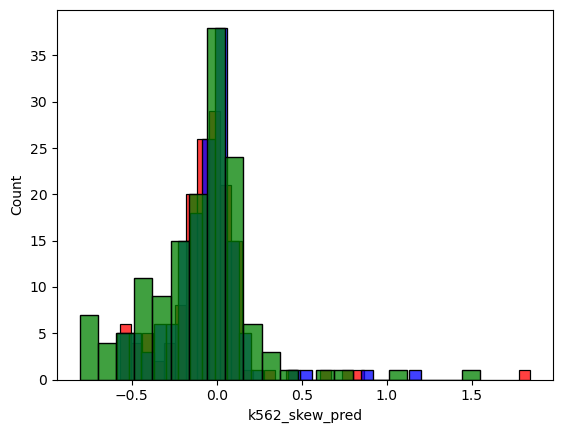

In [28]:
range = chr2_preds[(chr2_preds['pos'] >= 43426715) & (chr2_preds['pos'] <= 43426763)]
sns.histplot(data = range,
            x='k562_skew_pred', color = 'r')
sns.histplot(data = range,
            x='hepg2_skew_pred', color='b')
sns.histplot(data = range,
            x='sknsh_skew_pred', color ='g')

<Axes: xlabel='k562_ref_pred', ylabel='Count'>

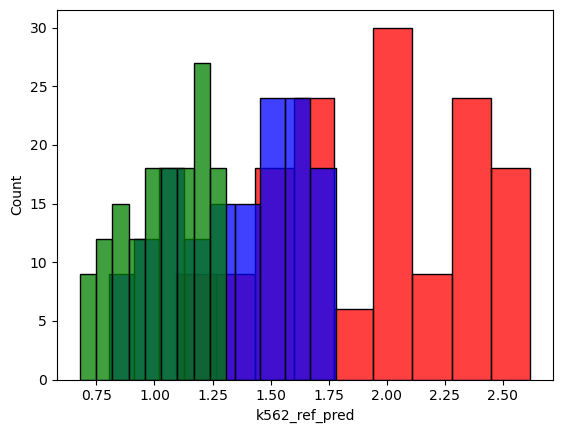

In [29]:
sns.histplot(data = range,
            x='k562_ref_pred', color = 'r')
sns.histplot(data = range,
            x='hepg2_ref_pred', color='b')
sns.histplot(data = range,
            x='sknsh_ref_pred', color ='g')

K562


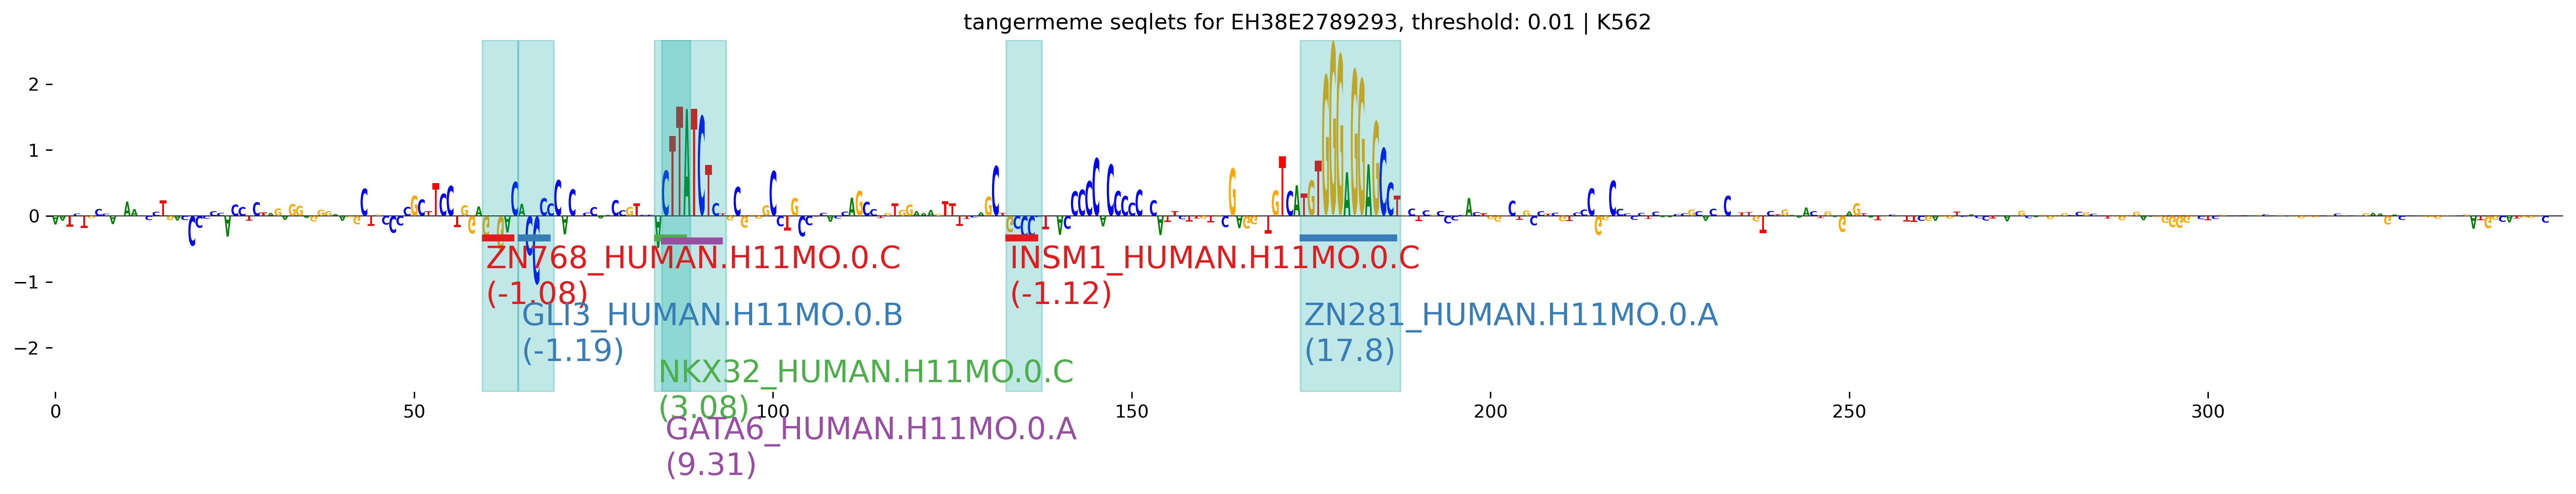

In [94]:
# chr1 16146497 16146498 COSV64452057
plot_logos_v2(
    1,
    'K562',
    'EH38E2789293'
)

K562


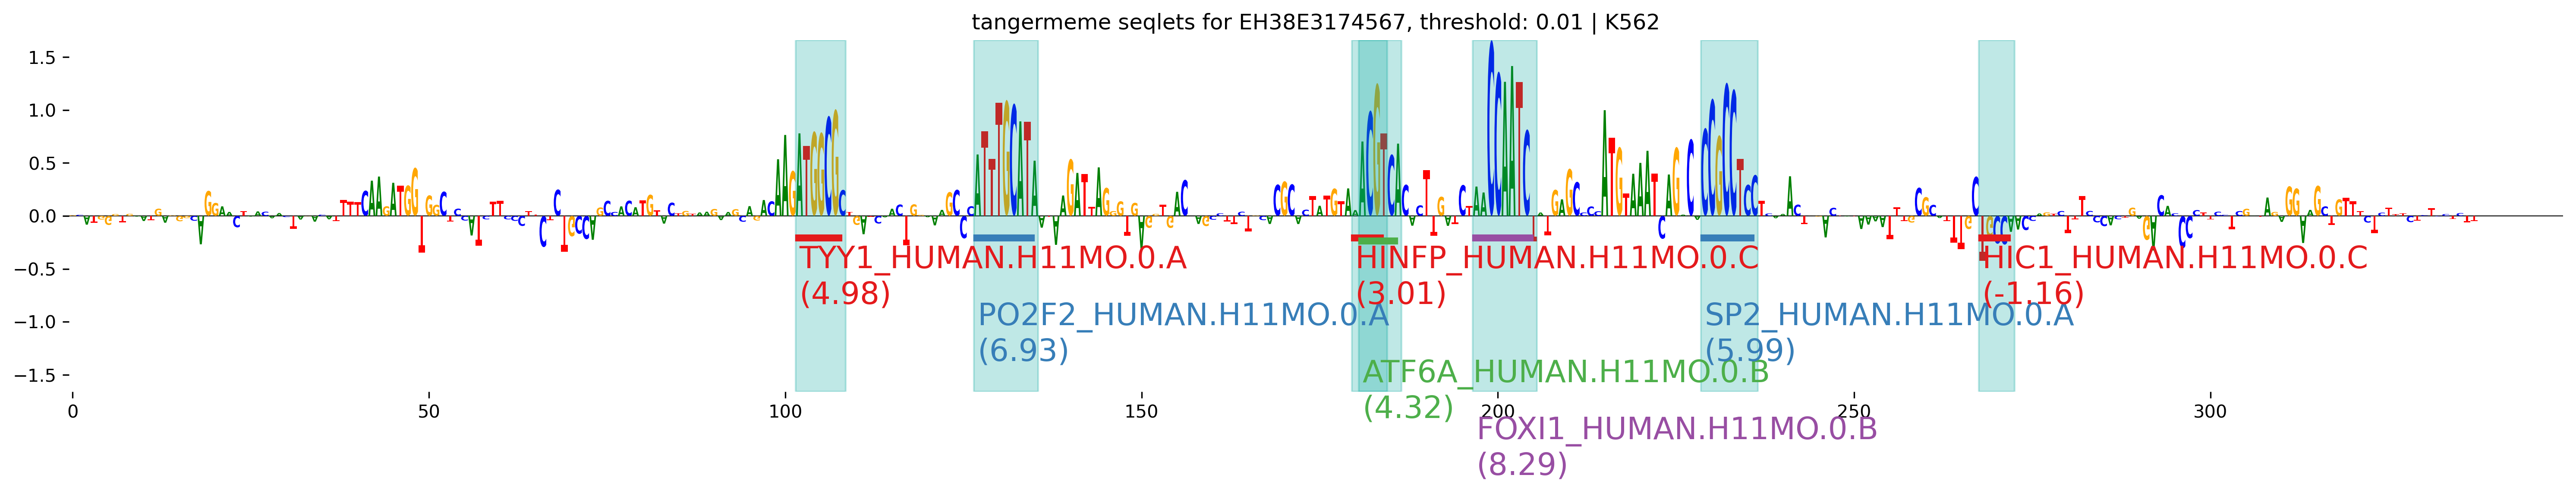

In [95]:
# chr16 27198936 27198937 COSV53730765
plot_logos_v2(
    16,
    'K562',
    'EH38E3174567'
)

K562


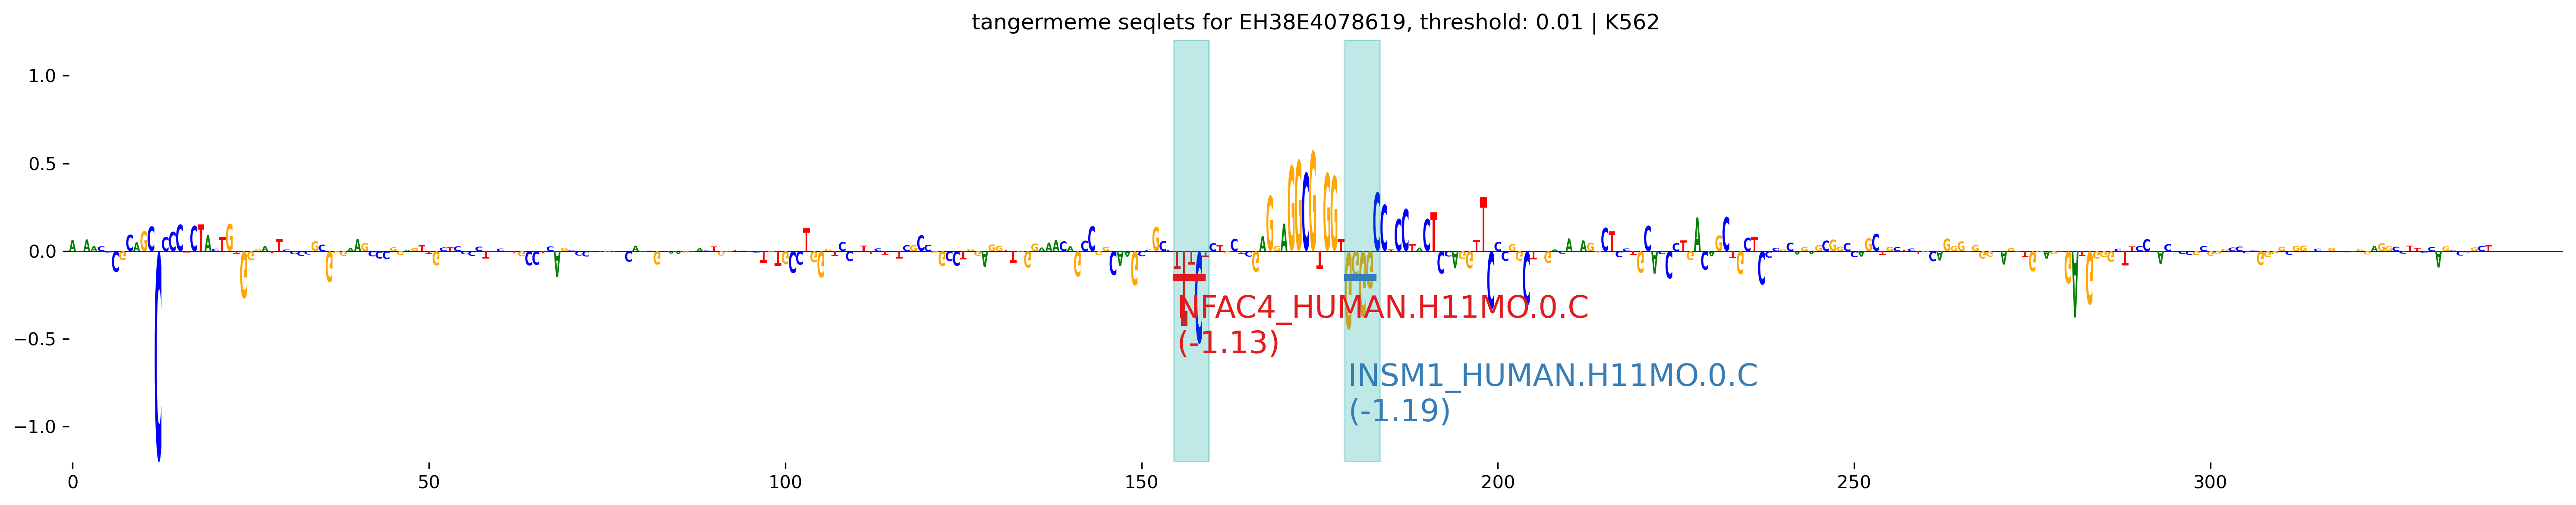

In [96]:
# chr12 122023950 122023951 COSV104379342 - in intron of BCL7A (cancer related gene)
plot_logos_v2(
    12,
    'K562',
    'EH38E4078619'
)

K562


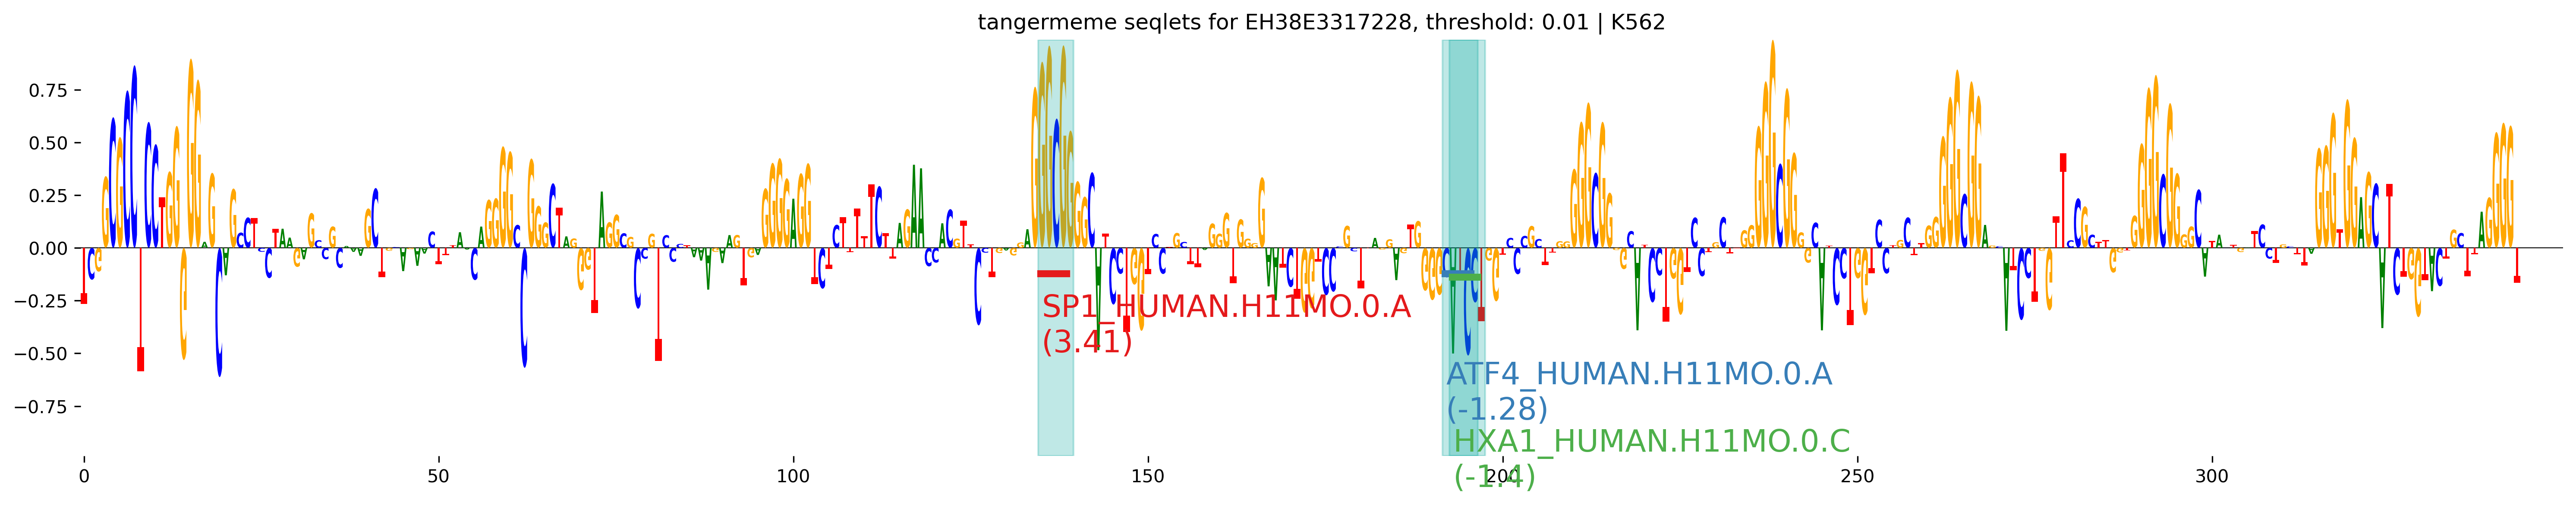

In [97]:
#  chr19 55174270 55174270 COSV62831248
plot_logos_v2(
    19,
    'K562',
    'EH38E3317228'
)

K562


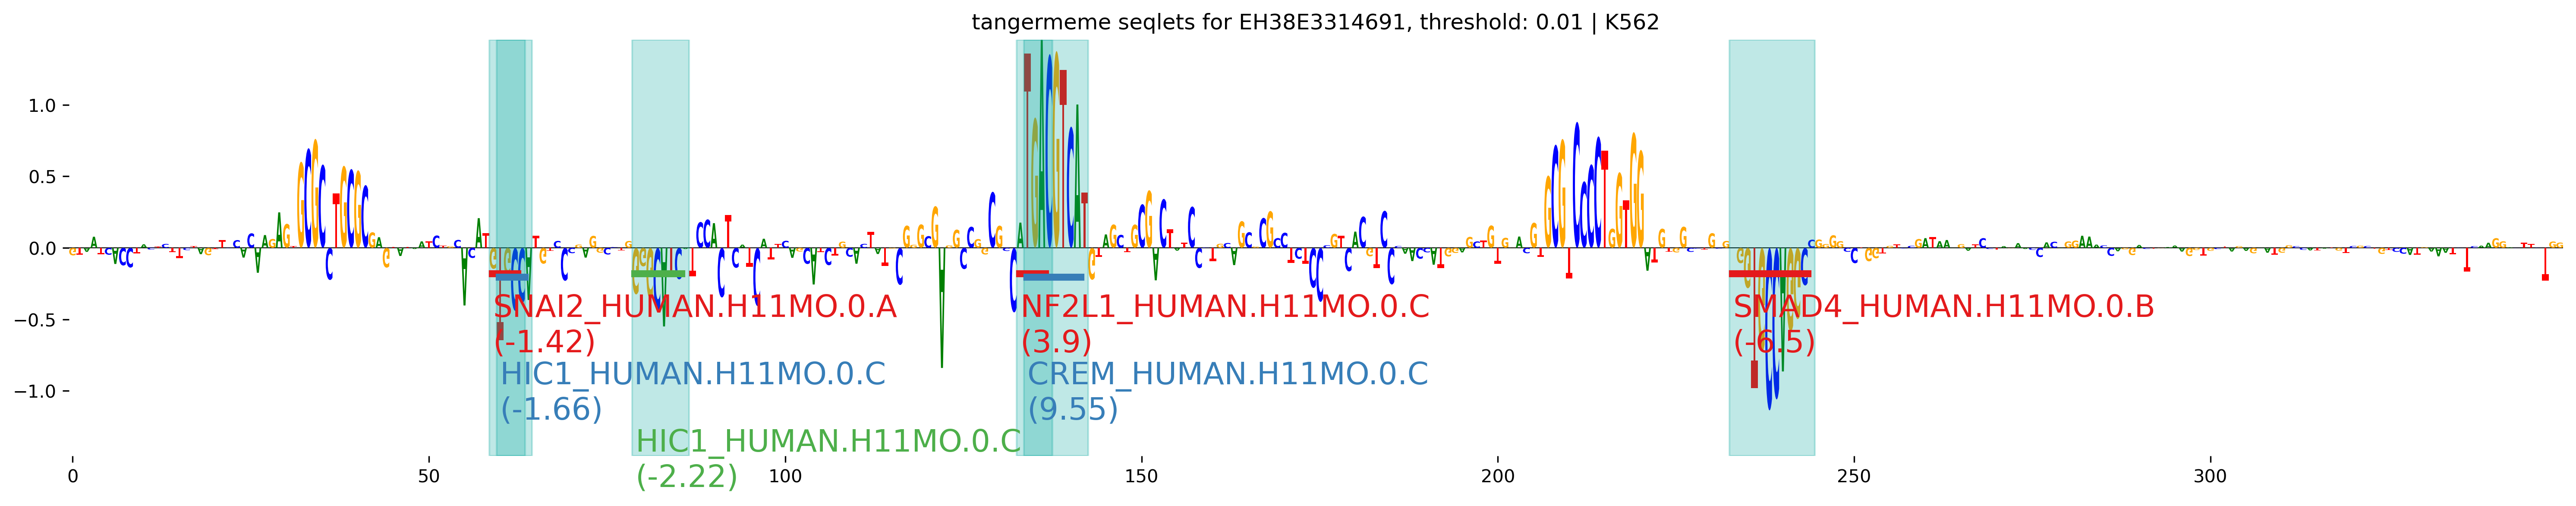

In [98]:
# chr19 50870485 50870486 COSV57569136 - not in seqlet (at about 40ish), however neighbors a GWAS variant also predicted to be high contribution
plot_logos_v2(
    19,
    'K562',
    'EH38E3314691'
)

K562


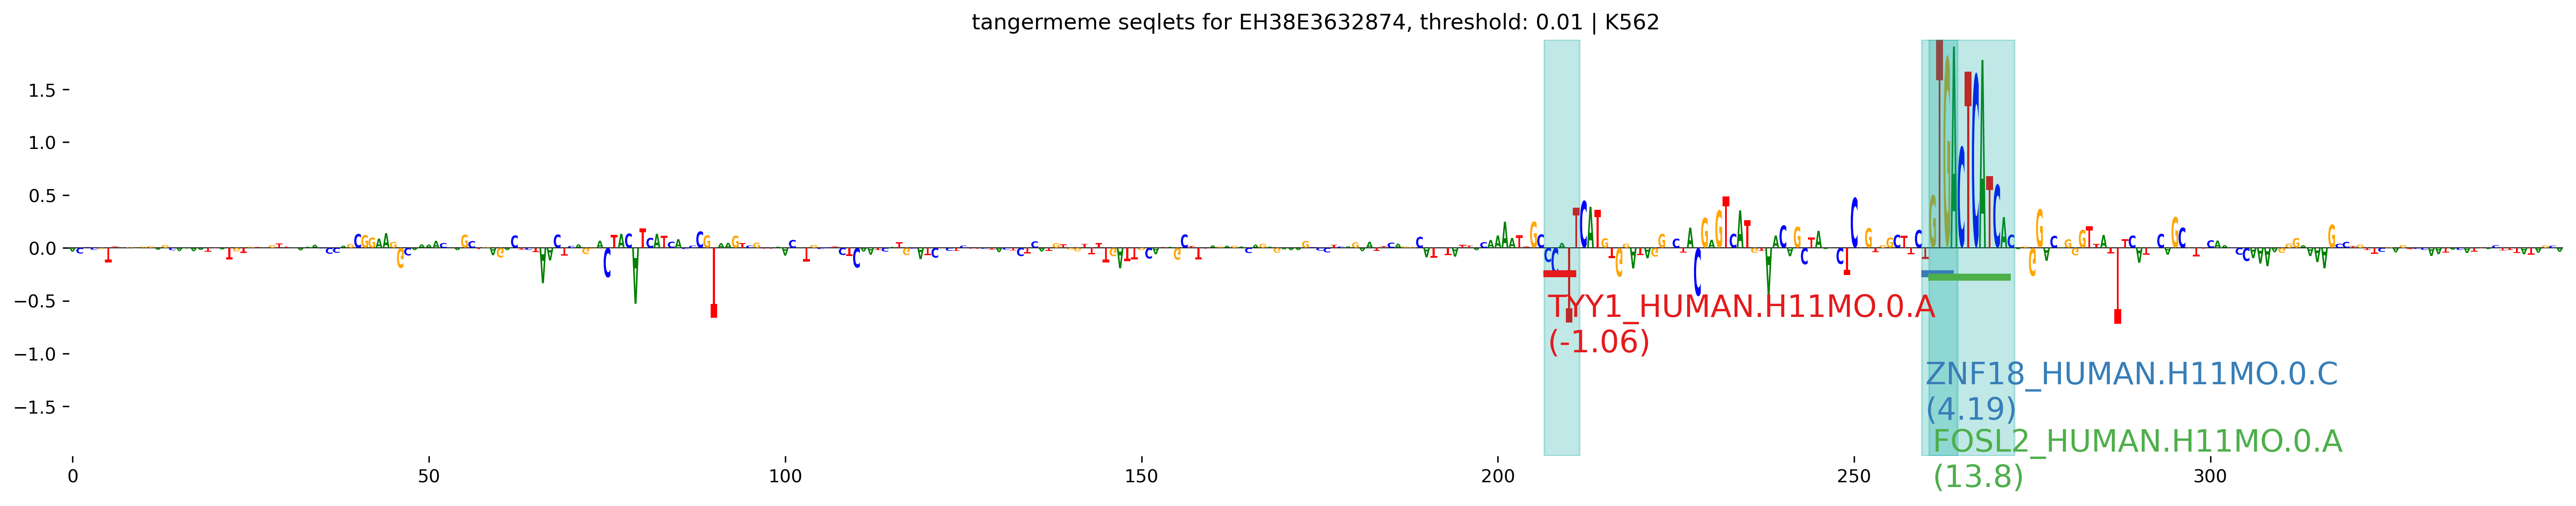

In [99]:
#chr5 37723095 37723096 COSV105019365
plot_logos_v2(
    5,
    'K562',
    'EH38E3632874'
)

K562


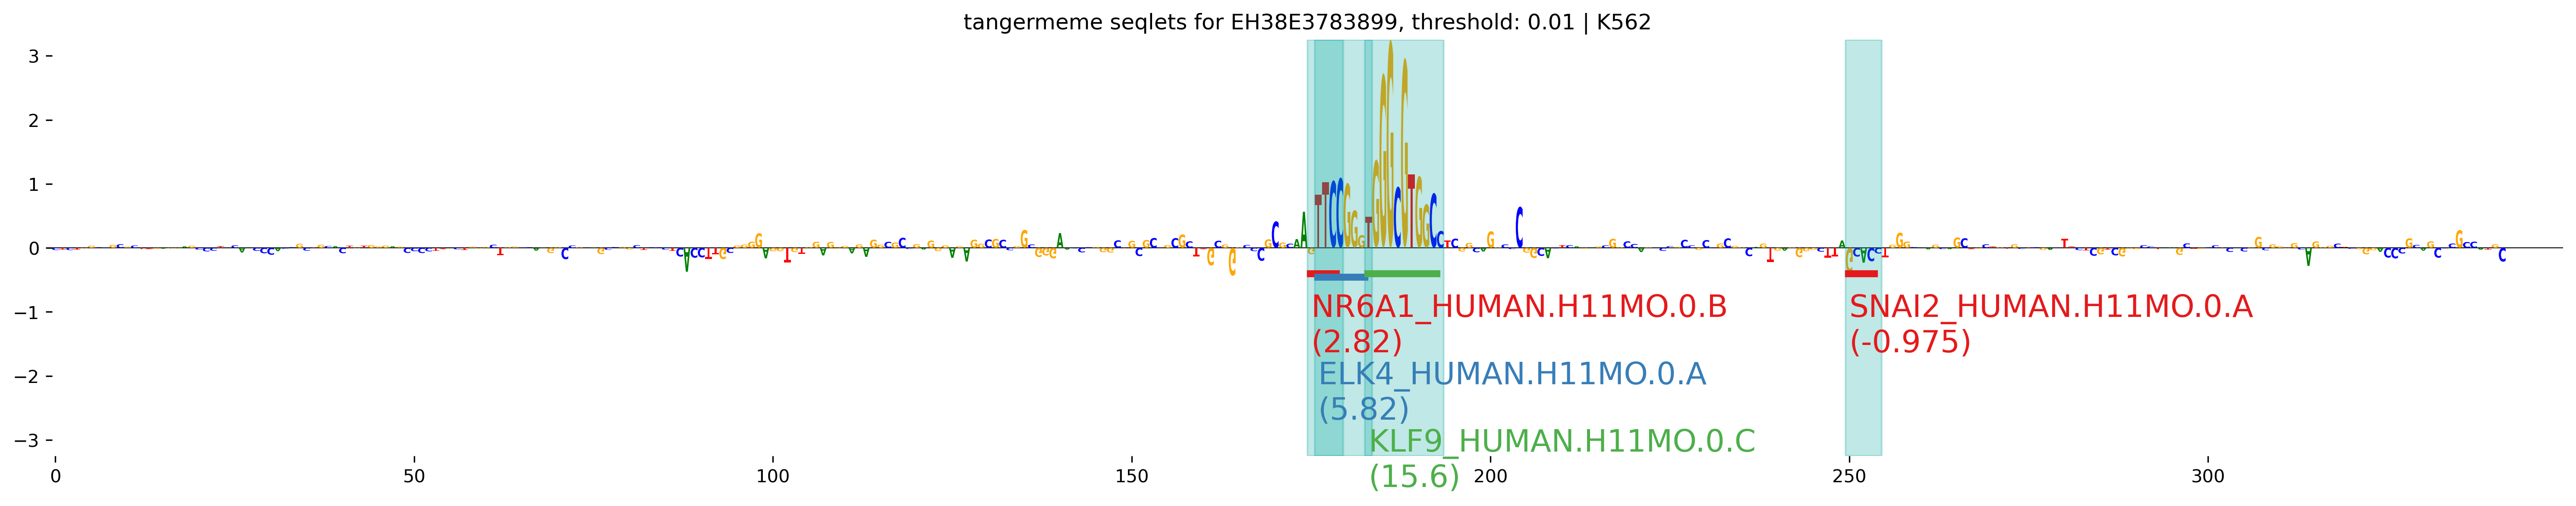

In [100]:
# chr7 84880640 84880641 COSV105938264
plot_logos_v2(
    7,
    'K562',
    'EH38E3783899'
)

K562


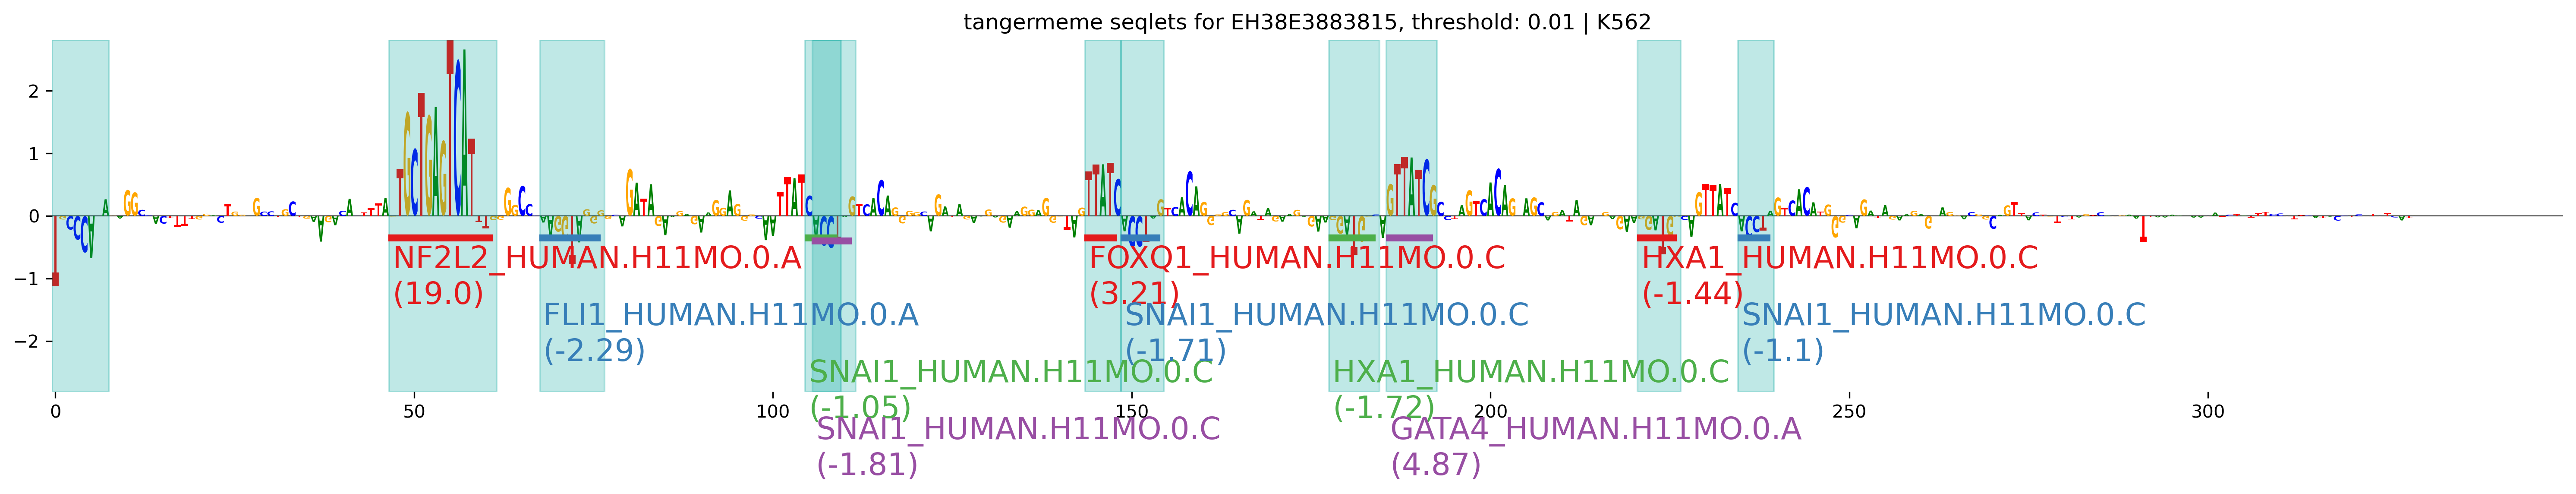

In [102]:
# chr9 63912692 63912693 COSV73857936
plot_logos_v2(
    9,
    'K562',
    'EH38E3883815'
)

HepG2


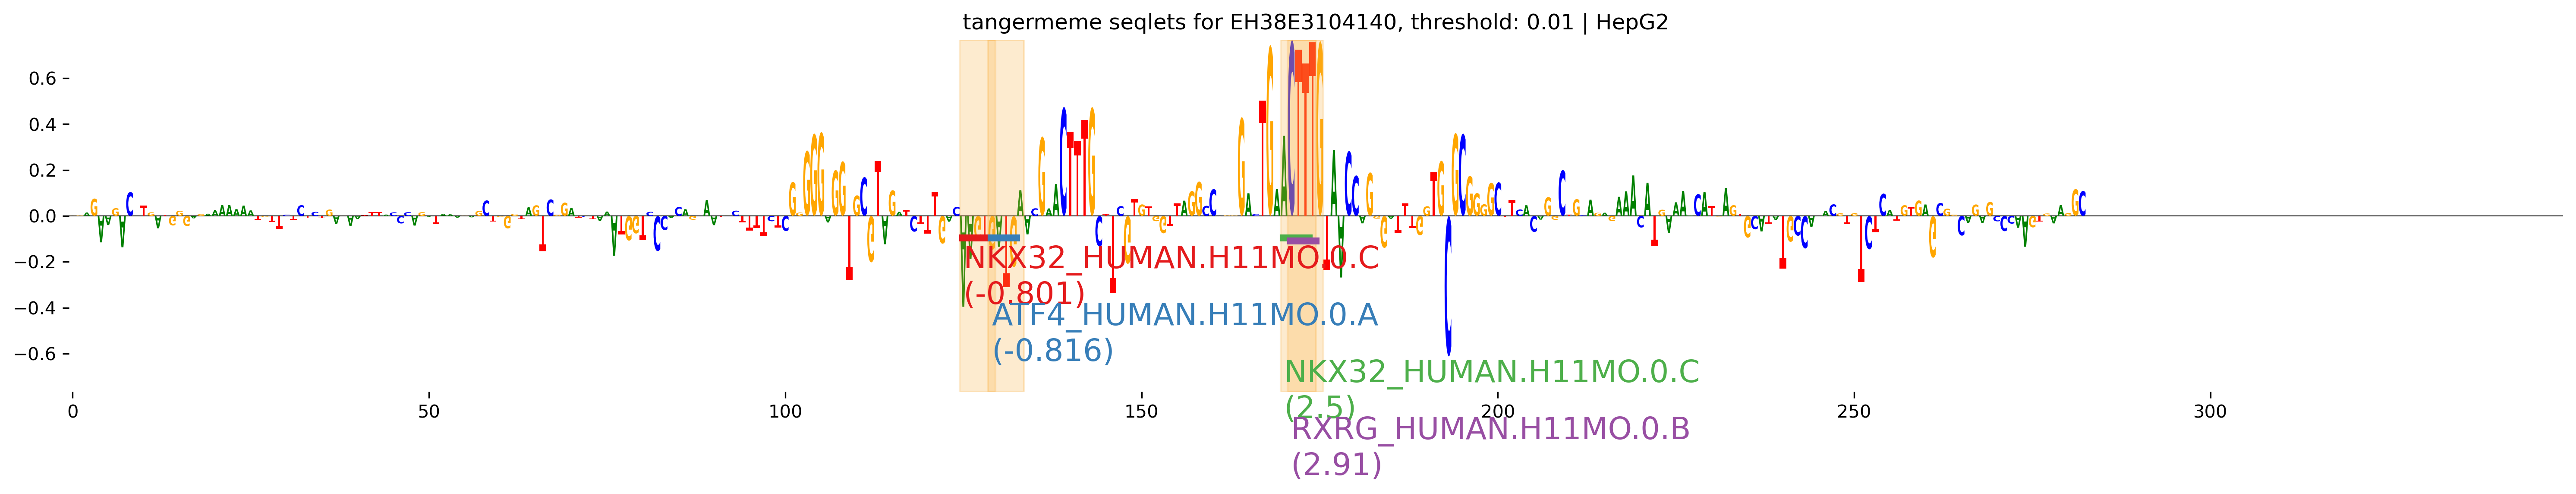

In [15]:
# chr14 	73478884 	73478885 	COSV58576208
plot_logos_v2(
    14,
    'HepG2',
    'EH38E3104140'
)

HepG2


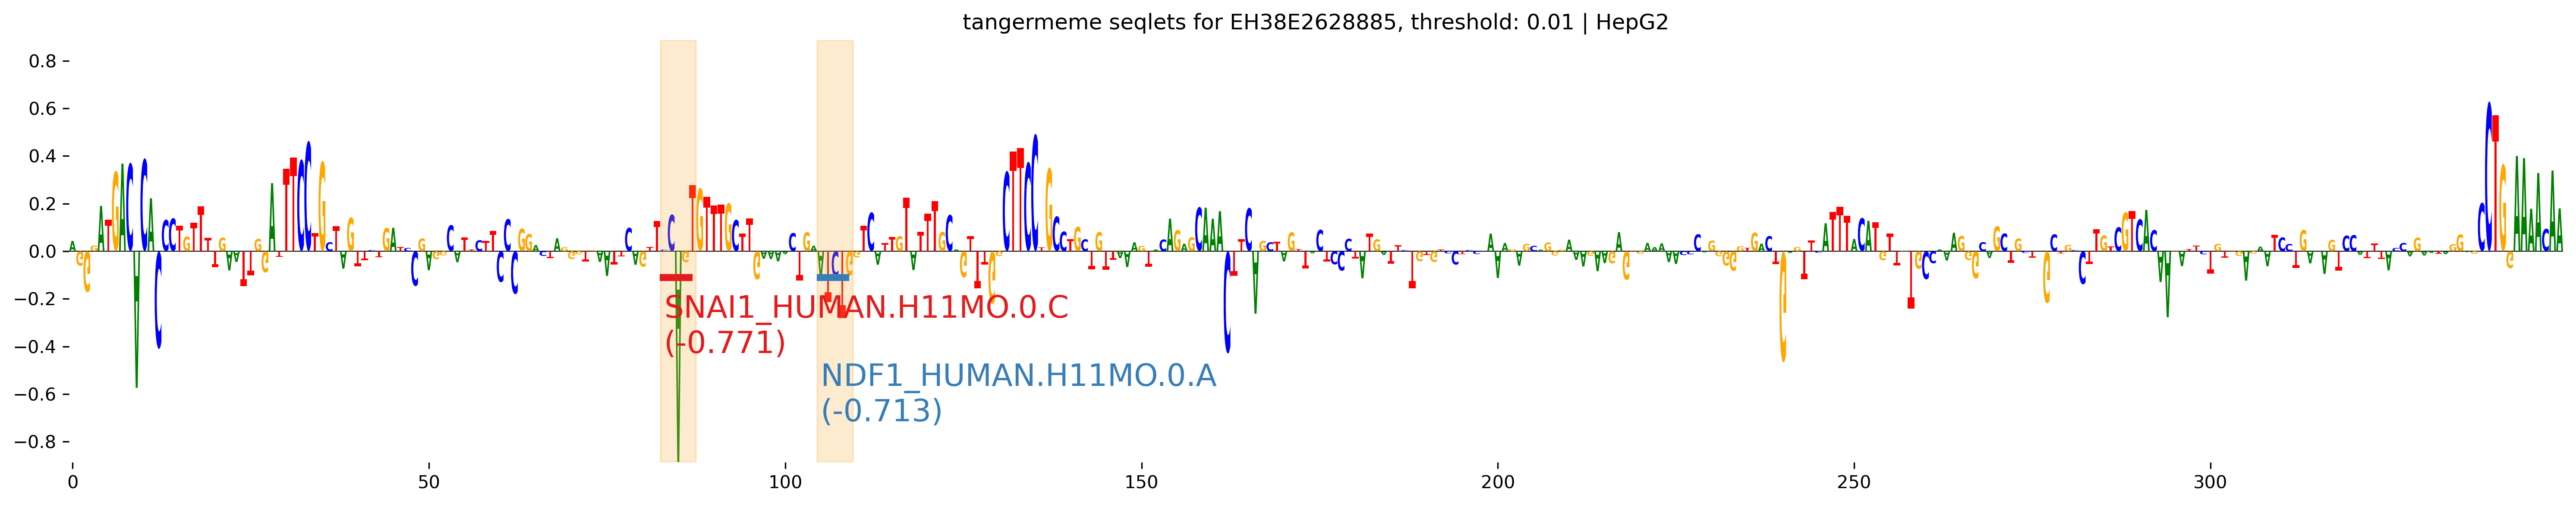

In [16]:
# chr8 	47525127 	47525128 	COSV52373280
plot_logos_v2(
    8,
    'HepG2',
    'EH38E2628885'
)